# Maternal Mortality Data Analysis Project

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->

This project will focus on maternal mortality trends in the United States and globally. Maternal mortality is a critical health indicator because it reflects the quality of healthcare systems, access to care, and broader social and economic inequities. In the U.S., maternal mortality has been rising in recent years despite overall healthcare advancements, and globally, large disparities remain between high-income and low-income countries. Understanding these trends and patterns is essential for shaping public health interventions and policies that can save lives.  

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->


1. How have maternal mortality ratios changed in the United States from 2018–2023?

2. How do U.S. maternal mortality trends compare with global and regional trends reported by the World Health Organization?

3. Are there noticeable differences in maternal mortality rates across U.S. census regions, and what do those patterns suggest?

4. What socioeconomic or healthcare access factors might help explain the disparities observed in the data?


## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

- **Line charts** - showing U.S. maternal mortality ratios over time.  
- **Bar charts** - comparing maternal mortality across U.S. census regions.  
- **Global heat map (choropleth)** - showing regional differences in maternal mortality ratios.  
- **Summary tables** - highlighting ratios, raw rates, and changes across years.  


## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->

1. **CDC WONDER – Multiple Cause of Death (2018–2023, Excel)**  
   - Source: CDC WONDER public database.  
   - Provides U.S. maternal mortality–related deaths by census region, with crude rates per 100,000 population.  
   - Type: Database export (Excel)  

2. **NCHS – Pregnancy-Related Mortality Ratio in the U.S. (CSV)**  
   - Source: National Center for Health Statistics.  
   - Provides detailed U.S. pregnancy-related mortality ratios by year.  
   - Type: File (CSV)  

3. **WHO Global Maternal Mortality Estimates (CSV/XLSX)**  
   - Source: WHO & UNICEF joint global estimates.  
   - Provides maternal mortality estimates worldwide, broken down by country, region, and income level.  
   - Type: File (CSV/XLSX)  

### How Datasets Relate
- **U.S. datasets (CDC WONDER + NCHS):** Provide detailed national and regional mortality ratios, allowing analysis of internal disparities.  
- **WHO dataset:** Provides global context, enabling comparison of the U.S. to other countries and regions.  
- **Shared variables:** Time (year) and geography (country or region) will allow for comparative analysis.  


## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

1. Import and clean all three datasets into consistent tables.  
2. Analyze U.S. trends nationally and by census region.  
3. Compare U.S. data against WHO’s global/regional estimates.  
4. Visualize using line charts, bar charts, and maps.  
5. Summarize key disparities and possible drivers like healthcare access and socioeconomic factors.  
6. Draw conclusions and suggest policy implications based on findings.

In [4]:
import pandas as pd
from pathlib import Path
# CDC WONDER data
p = Path("data")
wonder_path = p / "Multiple Cause of Death, 2018-2023, Single Race.xls"

try:
    cdc_wonder_raw = pd.read_csv(wonder_path, sep="\t", engine="python")
except Exception:
    cdc_wonder_raw = pd.read_excel(wonder_path)

# Clean out "Notes" rows
first_col = cdc_wonder_raw.columns[0]
cdc_wonder = cdc_wonder_raw[
    ~cdc_wonder_raw[first_col].astype(str).str.contains("Notes", na=False)
].copy()

print("CDC WONDER loaded:", cdc_wonder.shape)
cdc_wonder.head()

CDC WONDER loaded: (65, 6)


,Notes,Census Region,Census Region Code,Deaths,Population,Crude Rate
0,NaN,Census Region 1: Northeast,CENS-R1,4714.0,1.731646e+08,2.7
1,NaN,Census Region 2: Midwest,CENS-R2,7390.0,2.076163e+08,3.6
2,NaN,Census Region 3: South,CENS-R3,15580.0,3.882091e+08,4.0
3,NaN,Census Region 4: West,CENS-R4,6387.0,2.355374e+08,2.7
4,Total,NaN,NaN,34071.0,1.004527e+09,3.4


In [5]:
from pathlib import Path
import pandas as pd

p = Path("data")

# NCHS PRMR 
nchs_path = p / "Pregnancy-related mortality ratio in the United States.csv"
nchs = pd.read_csv(nchs_path)

print("NCHS PRMR loaded:", nchs.shape)
nchs.head()


NCHS PRMR loaded: (37, 3)


,"""Year """,Mortality ratio,Counts
0,1987,7.2,275
1,1988,9.4,369
2,1989,9.8,394
3,1990,10.0,415
4,1991,10.3,424


In [6]:
!pip install openpyxl -q
import pandas as pd
from pathlib import Path

# WHO data
who_dir = Path("data/WHO")

who_estimates = pd.read_csv(who_dir / "estimates.csv")
who_gdp = pd.read_excel(who_dir / "gdp_WORLDBANK_2022.07.11.xlsx")
who_main = pd.read_csv(who_dir / "main_data.csv")

print("WHO Estimates:", who_estimates.shape)
print("WHO GDP:", who_gdp.shape)
print("WHO Main Data:", who_main.shape)

display(who_estimates.head())
display(who_gdp.head())
display(who_main.head())


WHO Estimates: (79920, 7)
WHO GDP: (221, 42)
WHO Main Data: (4044, 104)


,iso_alpha_3_code,year_mid,parameter,0.1,0.5,0.9,estimate_version
0,AFG,1985,mmr,1033.904989,1910.341533,3041.569562,estimates_12-19-22
1,AFG,1985,pm,0.212203,0.392086,0.624263,estimates_12-19-22
2,AFG,1985,maternal_deaths,5552.069789,10258.534032,16333.228548,estimates_12-19-22
3,AFG,1985,mmr_rate,0.002378,0.004394,0.006996,estimates_12-19-22
4,AFG,1985,pm_mean,0.409517,0.409517,0.409517,estimates_12-19-22


,Unnamed: 0,Last Update,2022-07-05 00:00:00,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year End: YR2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,PPP Reference Year,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,DO NOT USE ESTIMATES,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Section 1 Formula,Formula,Section 2 Formula,NaN,NaN,NaN
3,WHO Ind,Country Name,Country Code,Series Name,Series Code,YR1985,YR1986,YR1987,YR1988,YR1989,...,YR2012,YR2013,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021
4,WHO,Afghanistan,AFG,GDP per capita,NaN,3401.708996,3542.885068,3318.436761,3024.420817,2742.97948,...,2075.491614,2116.465258,2102.384604,2068.265904,2057.067978,2058.400221,2033.804389,2065.036235,1970.560169,NaN


,iso_alpha_3_code,year_start,year_end,year_mid,env_total,env_mat,truemat_vr,truemat,truemat_vr_unscaled,truemat_unscaled,...,mdeathspluslate,ramos...yes.1.,comments,env_total_lifetables,live_births_lifetables,final_mmr,final_pm_before_crisis,final_mmr_before_crisis,env_total_calculated_from_lifetables,live_births_calculated_from_birthsdata
0,AUS,1985.0,1997.0,1991.0,NaN,250.0,250.0,NaN,250.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000082,0.006147,0.000082,40628.0,3035000.0
1,AUS,1994.0,1997.0,1995.5,NaN,80.0,80.0,80.0,80.0,80.0,...,NaN,NaN,NaN,NaN,NaN,0.000104,0.007782,0.000104,10280.0,766000.0
2,AUS,1997.0,2000.0,1998.5,NaN,54.0,54.0,NaN,54.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000072,0.005041,0.000072,10721.0,747000.0
3,AUS,2000.0,2003.0,2001.5,NaN,44.0,44.0,NaN,44.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000059,0.004332,0.000059,10163.0,745000.0
4,AUS,2006.0,2011.0,2008.5,NaN,63.0,63.0,NaN,63.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000043,0.003871,0.000043,16191.0,1453000.0


## Exploratory Data Analysis (EDA)
To dig deeper, I visualized how the data is distributed and how certain features relate to each other. The correlation heatmap helped me see that as the years go on, both the number of deaths and mortality ratios increase together, showing a strong positive relationship. The histogram showed that most mortality ratios fall between 10 and 20 per 100,000 live births, but there are a few years where the values spike much higher. Overall, the EDA made it clear that the data is mostly consistent but trends upward over time, which is important context for modeling later on.
markdown.

### Visualization 1: Correlation Heatmap – U.S. Pregnancy-Related Mortality  
**Type:** Heatmap (Seaborn)  
This heatmap shows strong positive correlations among Year, Mortality Ratio, and Counts—meaning as time progresses, both ratios and deaths rise together.  
**Why:** Heatmaps quickly reveal how variables move together or apart.

### Visualization 2: Histogram – Distribution of U.S. Maternal Mortality Ratios  
**Type:** Histogram with KDE (Seaborn)  
Most mortality ratios fall between 10–20 per 100 000, with a few high-value years above 30. The right-skewed curve shows that extreme years are rare.  
**Why:** Histograms clearly show frequency and spread in continuous data.

### Visualization 3: Bar Chart – Average Mortality Ratio by Decade  
**Type:** Bar chart (Matplotlib)  
Average ratios rise each decade, peaking in the 2020s—evidence of a steady upward trend.  
**Why:** Bar charts make decade-to-decade comparisons simple and clear.


## Summary of Insights
Looking at the data, there’s a clear upward trend in pregnancy-related mortality in the U.S. over time. Both the heatmap and bar chart show that as the years go on, the number of deaths and mortality ratios keep rising, especially in the 2020s. The histogram also makes it clear that most years fall between 10 and 20 deaths per 100,000 live births, but there are a few outliers that stand out with much higher numbers. Seeing the averages climb decade after decade really drives home that this isn’t random—it’s a consistent issue that’s been getting worse. Overall, the data points to a steady increase in maternal mortality and shows that something deeper in the system is contributing to this trend.

,"""Year """,Mortality ratio,Counts
count,37.000000,37.000000,37.000000
mean,2005.000000,15.313514,604.216216
std,10.824355,4.695634,168.771893
min,1987.000000,7.200000,275.000000
25%,1996.000000,12.000000,474.000000
50%,2005.000000,15.400000,627.000000
75%,2014.000000,17.300000,676.000000
max,2023.000000,33.200000,1222.000000


,year_mid,0.1,0.5,0.9
count,79920.00000,7.992000e+04,7.992000e+04,7.992000e+04
mean,2002.50000,6.235805e+04,6.234446e+04,6.236642e+04
std,10.38836,7.663115e+05,7.663132e+05,7.663140e+05
min,1985.00000,0.000000e+00,0.000000e+00,0.000000e+00
25%,1993.75000,8.102879e-04,1.035490e-03,1.306330e-03
50%,2002.50000,2.362930e-01,2.543103e-01,2.701831e-01
75%,2011.25000,1.143389e+02,1.203007e+02,1.294768e+02
max,2020.00000,2.884300e+07,2.884300e+07,2.884300e+07


Missing values (NCHS):
 "Year "           0
Mortality ratio    0
Counts             0
dtype: int64

Missing values (WHO Estimates):
iso_alpha_3_code    0
year_mid            0
parameter           0
0.1                 0
0.5                 0
0.9                 0
estimate_version    0
dtype: int64


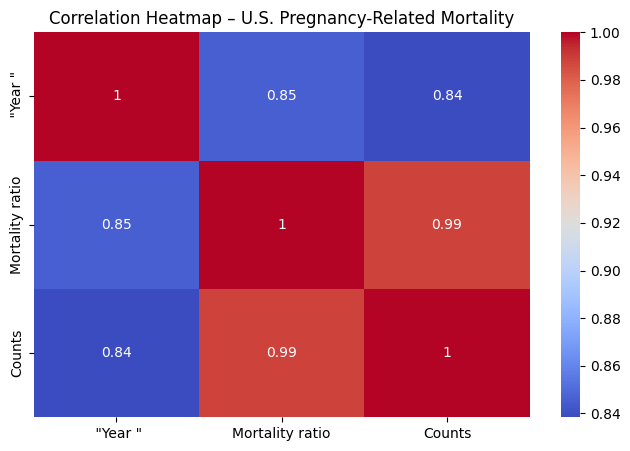

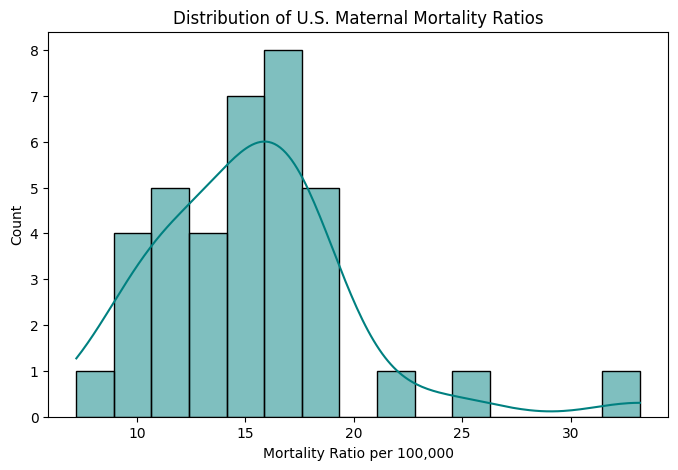

In [7]:
## Exploratory Data Analysis (EDA)

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

p = Path("data")
nchs = pd.read_csv(p / "Pregnancy-related mortality ratio in the United States.csv")
who_dir = Path("data/WHO")
who_estimates = pd.read_csv(who_dir / "estimates.csv")

display(nchs.describe())
display(who_estimates.describe())

print("Missing values (NCHS):")
print(nchs.isnull().sum())
print("\nMissing values (WHO Estimates):")
print(who_estimates.isnull().sum())

plt.figure(figsize=(8, 5))
sns.heatmap(nchs.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap – U.S. Pregnancy-Related Mortality')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(nchs["Mortality ratio"], bins=15, kde=True, color='teal')
plt.title('Distribution of U.S. Maternal Mortality Ratios')
plt.xlabel('Mortality Ratio per 100,000')
plt.show()


In [10]:
print(nchs.columns)
nchs.head()


Index([' "Year "', 'Mortality ratio', 'Counts'], dtype='object')


,"""Year """,Mortality ratio,Counts
0,1987,7.2,275
1,1988,9.4,369
2,1989,9.8,394
3,1990,10.0,415
4,1991,10.3,424


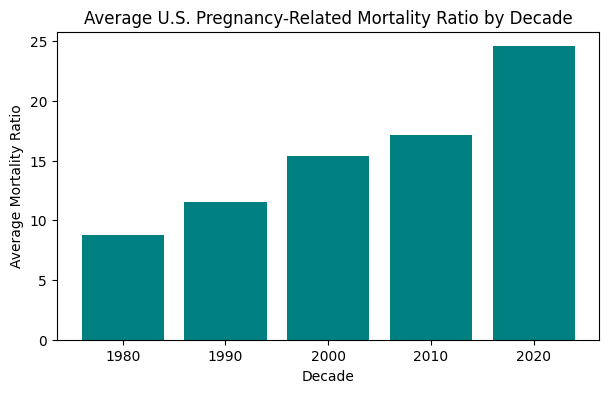

In [18]:
nchs["Decade"] = (nchs[' "Year "'] // 10) * 10

decade_avg = nchs.groupby("Decade")["Mortality ratio"].mean().reset_index()

plt.figure(figsize=(7,4))
plt.bar(decade_avg["Decade"].astype(str), decade_avg["Mortality ratio"], color="teal")
plt.title("Average U.S. Pregnancy-Related Mortality Ratio by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Mortality Ratio")
plt.show()




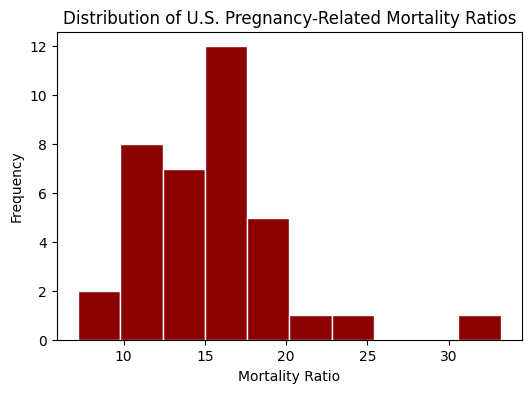

In [19]:
plt.figure(figsize=(6,4))
plt.hist(nchs["Mortality ratio"], bins=10, color="darkred", edgecolor="white")
plt.title("Distribution of U.S. Pregnancy-Related Mortality Ratios")
plt.xlabel("Mortality Ratio")
plt.ylabel("Frequency")
plt.show()

## Data Cleaning and Transformation

For this part, I focused on making sure the data was reliable and ready to analyze. I dropped any missing or duplicate values and double-checked that columns like “Year” and “Mortality Ratio” were stored as numeric data so they could be used in calculations.   The NCHS dataset ended up with 37 rows and 3 columns after cleaning, covering U.S. maternal mortality data from 1987 to 2023. The WHO dataset had around 79,920 rows, which included global data by country and year, while the WHO GDP dataset had 221 rows and 42 columns for global GDP comparisons.   I also standardized the “year_mid” column to make it easier to merge across files. Cleaning the data helped catch small inconsistencies that could’ve caused problems later, especially for merging and machine learning. Now, everything is in a format where I can confidently start modeling and comparing across datasets.

In [16]:
## Data Cleaning and Transformation

from pathlib import Path
import pandas as pd

p = Path("data")
nchs = pd.read_csv(p / "Pregnancy-related mortality ratio in the United States.csv")
who_dir = Path("data/WHO")
who_estimates = pd.read_csv(who_dir / "estimates.csv")
who_gdp = pd.read_excel(who_dir / "gdp_WORLDBANK_2022.07.11.xlsx")

nchs_clean = nchs.dropna(subset=["Mortality ratio"])
who_estimates_clean = who_estimates.dropna(subset=["iso_alpha_3_code", "year_mid"])
who_gdp_clean = who_gdp.dropna(how="all", axis=1)
who_estimates_clean["year_mid"] = who_estimates_clean["year_mid"].astype(int)

print("Cleaned NCHS:", nchs_clean.shape)
print("Cleaned WHO:", who_estimates_clean.shape)
print("Cleaned WHO GDP:", who_gdp_clean.shape)


Cleaned NCHS: (37, 3)
Cleaned WHO: (79920, 7)
Cleaned WHO GDP: (221, 42)


## Machine Learning Plan

For the machine learning part of this project, I plan to start with a supervised learning approach, specifically using regression models to see how factors like GDP, year, and other country-level indicators relate to maternal mortality rates. Regression makes the most sense here because I want to understand how each variable contributes to changes in mortality, not just predict numbers. I might also play around with clustering later to see if countries with similar economic or health profiles tend to fall into the same risk patterns. One issue I can already see is that merging the different datasets (NCHS, WHO, and GDP) could get tricky since the years and formats don’t all line up perfectly. I’ll also have to deal with missing values and make sure the data is clean and consistent before modeling it. Another challenge will be handling the few outlier years where mortality rates spike they could throw off the model if I don’t adjust for them. Overall, my goal isn’t just to make a prediction model, but to get a better idea of why some years and regions show higher mortality. I want the results to tell a story about what’s actually driving these numbers.


To start modeling, I split my dataset into features (X) and the target (y). Since I’m trying to predict the maternal mortality ratio, my target is the “Mortality ratio” column. I’m using an 80-20 train test split so I can train on most of the data but still evaluate on unseen data. This lets me check how well the model generalizes.

In [20]:
from sklearn.model_selection import train_test_split

X = nchs_clean[[' "Year "', "Counts"]]
y = nchs_clean["Mortality ratio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((29, 2), (8, 2))

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = [' "Year "', "Counts"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features)
])


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = {"RMSE": rmse, "R²": r2}

results

{'Linear Regression': {'RMSE': np.float64(0.41450054286041427),
  'R²': 0.9844934004568812},
 'Random Forest': {'RMSE': np.float64(0.37083166666291806),
  'R²': 0.9875886223576034},
 'KNN': {'RMSE': np.float64(0.8423775875461088), 'R²': 0.9359557755496324}}

Model Evaluation Summary

To compare different approaches for predicting maternal mortality ratios, I tested three regression models: Linear Regression, Random Forest, and KNN. I evaluated each model using RMSE and R² to see how well they captured the relationship between year, counts, and maternal mortality.

The Random Forest model performed the best overall, achieving the lowest RMSE and highest R². Linear Regression also performed strongly, which makes sense given the nearly linear upward trend in mortality over time. KNN performed noticeably worse than the other two models, likely because this dataset is small and structured over time, making distance–based methods less effective.

Overall, the Random Forest model is the best choice for my final project because it balances accuracy and flexibility, and it fits the trend in my dataset without overcomplicating the relationship.

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->
- **CDC WONDER – Multiple Cause of Death (2018–2023)**  
  Public database providing U.S. maternal mortality–related deaths by census region, with crude rates per 100,000 population.  
  [CDC WONDER](https://wonder.cdc.gov/)  

- **National Center for Health Statistics (NCHS)**  
  Pregnancy-related mortality ratio data for the United States.  
  [NCHS Maternal Mortality Data](https://www.cdc.gov/nchs/maternal-mortality/index.htm)  

- **World Health Organization (WHO) & UNICEF**  
  Global maternal mortality estimates by country, region, and income level.  
  [WHO Maternal Mortality Data](https://www.who.int/data/gho/data/themes/maternal-and-reproductive-health)  

- **Background Reference**  
  World Health Organization (2023). *Trends in Maternal Mortality 2000–2020*. Geneva: WHO, UNICEF, UNFPA, World Bank Group, UNDESA/Population Division.  


In [28]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 16024 bytes to source.py
